# **Práctica 6 : Detección y comparación de huellas dactilares**
**Autores**: Luna Yue Hernández Guerra y Jorge Lorenzo Lorenzo

**Fecha**: Diciembre 2025

**Asignatura**: Procesamiento de Imágenes, Audio y Vídeo

---

## **Hipotésis Base**
La hipótesis base se encuentra explicada en el archivo `Hipotesis_No_IA.md`.



## **Desarrollo**
**Librerías necesarias**

Se han utilizado las siguientes librerías:


In [ ]:
from fileinput import filename
import os
import cv2 as cv
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import norm
import json
import pandas as pd


### **Preprocesamiento**
A continuación, se exponen los diferentes pasos del preprocesado de las imágenes llevados a cabo. Estos pasos son secuenciales, es decir, cada uno se aplica a los resultados del paso anterior. Los pasos son los siguientes:
1. Buscar y segmentar la ROI
2. Ecualizar y normalizar el histograma
3. Aplicar un filtro bilateral
4. Aplicar un realce de crestas
5. Refinar la ROI

#### **Buscar y segmentar la ROI**
El objetivo del primer paso del preprocesado es obtener el núcleo de la huella. Según el estudio de Simón-Zorita, este paso es realmente importante para conseguir un buen preprocesado de huellas.

Para ello, creamos dos funciones: `mejor_roi()` y `recortar_roi()`.
- `mejor_roi()`: Esta función obtiene la región de interés de una imagen. Dicha región de interés se define como la región de tamaño `ventana`x`ventana` donde más píxeles negros hay. Para ello, se recorre la imagen con un kernel de tamaño `ventana`x`ventana` dando pasos de `paso` píxeles y se obtiene la suma de píxeles negros. Una vez recorrida toda la imagen, se devuelven las coordenadas donde inicia la ventana y el ancho y alto de la misma, con lo que se pueden calcular las coordenadas de la región con mayor número de píxeles negros.
- `recortar_roi()`: Esta función guarda las regiones de interés de todas las imágenes que se encuentran en la ruta `db_path` en disco, en un directorio `out_path` especificado. Para ello, hace uso de la función `mejor_roi()` tras convertir las imágenes a escala de grises y binarizarlas usando `cv.THRESH_BINARY + cv.THRESH_OTSU`. La binarización combinada es sugerencia de ChatGPT para que el umbral se establezca dinámicamente.

Pedimos a Gemini y fragmento de código para aceptar tanto la estructura de 'data' como de 'test' y acelerar el procesamiento.

In [23]:
def mejor_roi(image, ventana=500, paso=20):
    """Encuentra la región de interés (ROI) en la imagen que contiene la mayor cantidad de píxeles negros."""

    H, W = image.shape
    w = min(ventana, W, H)
    h = min(ventana, W, H)
    mejor_ventana = (0, 0, w, h)
    mejor_suma = -1

    for y in range(0, H - h + 1, paso):
        for x in range(0, W - w + 1, paso):
            region = image[y:y+h, x:x+w]
            suma = np.sum(region == 0)

            if suma > mejor_suma:
                mejor_suma = suma
                mejor_ventana = (x, y, w, h)

    return mejor_ventana

def recortar_roi(db_path, out_path, ventana=500, paso=15):
    """
    Detecta si db_path contiene carpetas de usuarios (Data) o imágenes sueltas (Test)
    y aplica el recorte ROI guardando en la estructura correspondiente.
    """

    if not os.path.exists(db_path):
        return

    items = os.listdir(db_path)

    # Código proporcionado por Gemini para aceptar 
    # tanto la estructura de 'data' como de 'test'
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        dst_folder = os.path.join(out_path, "roi")
        origen_dest_pares.append((db_path, dst_folder))
    else: # data
        for user in users:
            src = os.path.join(db_path, user)
            dst = os.path.join(out_path, user, "roi")
            origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        files = [f for f in os.listdir(src_dir) if f.lower().endswith(".png")]
    # ---

        for filename in files:
            img_path = os.path.join(src_dir, filename)
            img = cv.imread(img_path)

            if img is None: continue

            gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            _, image = cv.threshold(gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU) # Otsu: sugerencia de GPT
            x, y, w, h = mejor_roi(image, ventana=ventana, paso=paso)
            roi = img[y:y+h, x:x+w]
            cv.imwrite(os.path.join(dst_dir, filename), roi)

#### **Ecualizar y normalizar el histograma**
El siguiente paso a realizar es ecualizar y normalizar el histograma. Con esto, queremos mejorar el contraste de la imagen. Esta técnica la aprendimos en prácticas anteriores donde ecualizar el histograma de una imagen nos permitía encontrar un equilibrio entre brillos y sombras. Para ello,  usamos la función `ecualizar_histograma()`.
- `ecualizar_histograma()`: Esta función, para cada imagen que se encuentra en `db_path`, convierte la imagen a escala de grises, ecualiza el histograma con `cv.equalizeHist()` y la guarda en disco en el directorio `out_path` especificado.

Se utiliza la misma estructura que en la función anterior para procesar datos de entrenamiento y de evaluación.

In [24]:
def ecualizar_histograma(db_path, out_path):
    """Ecualiza y normaliza el histograma de las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        src = os.path.join(out_path, "roi")
        dst = os.path.join(out_path, "equalized")
        if os.path.isdir(src):
            origen_dest_pares.append((src, dst))
    else: # data
        for user in users:
            src = os.path.join(out_path, user, "roi")
            dst = os.path.join(out_path, user, "equalized")
            if os.path.isdir(src):
                origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path)
            if image is None: continue
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            equalized = cv.equalizeHist(gray)
            cv.imwrite(os.path.join(dst_dir, filename), equalized)

#### **Aplicar un filtro bilateral**
A continuación, procedemos con la aplicación del filtro bilateral, cuyo objetivo es eliminar ruido pero no las texturas. Este procedimiento lo aprendimos en prácticas anteriores donde vimos la efectividad de los distintos tipos de filtros. De dicha práctica, sacamos la conclusión de que si no queremos difuminar demasiado la imagen, debíamos utilizar valores bajos de *sigma*. Para aplicarlo, definimos la función `aplicar_filtro_bilateral()`.
- `aplicar_filtro_bilateral()`: Esta función convierte cada imagen ubicada dentro de `db_path` en escala de grises y le aplica el filtro bilateral con la función `cv.bilateralFilter`. Los resultados los guarda en disco en el directorio `out_path` especificado.

Se utiliza la misma estructura que en las funciones anteriores para procesar datos de entrenamiento y de evaluación.

In [25]:
def aplicar_filtro_bilateral(db_path, out_path):
    """Aplica un filtro bilateral a las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        src = os.path.join(out_path, "equalized")
        dst = os.path.join(out_path, "bilateral_filter")
        if os.path.isdir(src):
            origen_dest_pares.append((src, dst))
    else: # data
        for user in users:
            src = os.path.join(out_path, user, "equalized")
            dst = os.path.join(out_path, user, "bilateral_filter")
            if os.path.isdir(src):
                origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path)
            if image is None: continue
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            bilateral = cv.bilateralFilter(gray, d=10, sigmaColor=10, sigmaSpace=10)
            cv.imwrite(os.path.join(dst_dir, filename), bilateral)

#### **Aplicar un realce de crestas**
El siguiente paso, es realizar el realce de crestas con operadores de bordes Sobel con el fin de poder discriminar mejor entre crestas y valles. Este paso es una implementación de la teoría explicada en la primera parte de la asignatura. Para ello, creamos la función `realzar_crestas()`.
- `realzar_crestas()`:  Esta función convierte a escala de grises cada imagen de la base de datos ubicada en `db_path` y le aplica los operadores de Sobel, tanto verticales como horizontales. La ponderación de cada gradiente la obtuvimos de la [documentación de OpenCV](#https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html). Por último, se normaliza la imagen resultante y se pasa a `CV_8U` para solventar el *warning* `[ WARN:0@0.762] global loadsave.cpp:1063 cv::imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.`. Esto fue la solución al *warning* que nos dio ChatGPT. Los resultados los guarda en disco en el directorio `out_path` especificado.

Se utiliza la misma estructura que en las funciones anteriores para procesar datos de entrenamiento y de evaluación.

In [26]:
def realzar_crestas(db_path, out_path):
    """Aplica un realce de crestas a las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        src = os.path.join(out_path, "bilateral_filter")
        dst = os.path.join(out_path, "sobel")
        if os.path.isdir(src):
            origen_dest_pares.append((src, dst))
    else: # data
        for user in users:
            src = os.path.join(out_path, user, "bilateral_filter")
            dst = os.path.join(out_path, user, "sobel")
            if os.path.isdir(src):
                origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith('.png')]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path)
            if image is None: continue
            gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
            sobelx = cv.Sobel(gray, cv.CV_64F, 1, 0, ksize=3)
            sobely = cv.Sobel(gray, cv.CV_64F, 0, 1, ksize=3)
            # https://docs.opencv.org/4.x/d2/d2c/tutorial_sobel_derivatives.html
            abs_grad_x = cv.convertScaleAbs(sobelx)
            abs_grad_y = cv.convertScaleAbs(sobely)
            grad = cv.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0)
            sobel_8u = cv.normalize(grad, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8) # Código de GPT para solventar warning: [ WARN:0@0.762] global loadsave.cpp:1063 cv::imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.
            cv.imwrite(os.path.join(dst_dir, filename), sobel_8u)

#### **Refinar la ROI**
El último paso del preprocesado es refinar la región de interés. El objetivo es eliminar los bordes falsos que se hayan podido detectar en el paso anterior. Este procedimiento es una idea del artículo de Simón-Zorita y se lo pedimos al ChatGPT. La función obtenida es `refinar_roi()`.
- `refinar_roi()`: Esta función recorta el 8% de los márgenes de la imagen con el fin de eliminar los bordes que no pertenecen a la huella. Seguidamente, elimina el posible ruido más pequeño que el `kernel` y luego aplica un filtro mediano, que trata de eliminar el ruido sal-pimienta. Finalmente, normaliza la imagen. Este procedimiento lo aplica a todas las imágenes  que se encuentran en `db_path` y guarda los resultados en disco en el directorio `out_path` especificado. 

Se utiliza la misma estructura que en las funciones anteriores para procesar datos de entrenamiento y de evaluación.

In [27]:
def refinar_roi(db_path, out_path):
    """Refina la ROI de las imágenes en db_path y guarda los resultados en out_path."""

    items = os.listdir(db_path)
    test_images = [f for f in items if f.lower().endswith(('.png', '.jpg'))]
    users = [d for d in items if os.path.isdir(os.path.join(db_path, d))]

    origen_dest_pares = []

    if len(test_images) > 0: # test
        src = os.path.join(out_path, "sobel")
        dst = os.path.join(out_path, "refinadas")
        if os.path.isdir(src):
            origen_dest_pares.append((src, dst))
    else: # data
        for user in users:
            src = os.path.join(out_path, user, "sobel")
            dst = os.path.join(out_path, user, "refinadas")
            if os.path.isdir(src):
                origen_dest_pares.append((src, dst))

    for src_dir, dst_dir in origen_dest_pares:
        os.makedirs(dst_dir, exist_ok=True)
        image_files = [f for f in os.listdir(src_dir) if f.lower().endswith(".png")]

        for filename in image_files:
            img_path = os.path.join(src_dir, filename)
            image = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
            if image is None: continue

            h, w = image.shape
            pct = 0.08
            m = int(min(h, w) * pct)
            crop = image[m:h-m, m:w-m]
            kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
            clean = cv.morphologyEx(crop, cv.MORPH_OPEN, kernel, iterations=1)
            clean = cv.medianBlur(clean, 3)
            refinada = cv.normalize(clean, None, 0, 255, cv.NORM_MINMAX)
            cv.imwrite(os.path.join(dst_dir, filename), refinada)

#### **Ejecución del preprocesado**
A continuación, ejecutamos el preprocesado usando las funciones definidas anteriormente. El resultado será un nuevo directorio `output` que contendrá subdirectorios con los nombres de los archivos de los diferentes usuarios y un subdirectorio `test`. Todos ellos contienen otros directorios con las salidas del preprocesado de las imágenes de la base de datos y las utilizadas para testear.

In [28]:
DB_PATH = r"data"
OUT_PATH = "output"

TEST_PATH = "test"
OUT_TEST_PATH = "output/test"

print(20*"=")
print("PREPROCESADO BASE DE DATOS (DATA)")
print(20*"=")

print("Paso 1. ROI (Data)")
recortar_roi(DB_PATH, OUT_PATH, ventana=500, paso=15)  
print("Paso 2. Ecualizar (Data)")
ecualizar_histograma(DB_PATH, OUT_PATH)
print("Paso 3. Bilateral (Data)")
aplicar_filtro_bilateral(DB_PATH, OUT_PATH)
print("Paso 4. Sobel (Data)")
realzar_crestas(DB_PATH, OUT_PATH)
print("Paso 5. Refinar (Data)")
refinar_roi(DB_PATH, OUT_PATH)

print(20*"=")
print("PREPROCESADO IMÁGENES DE TEST")
print(20*"=")

print("Paso 1. ROI (Test)")
recortar_roi(TEST_PATH, OUT_TEST_PATH, ventana=500, paso=15)
print("Paso 2. Ecualizar (Test)")
ecualizar_histograma(TEST_PATH, OUT_TEST_PATH)
print("Paso 3. Bilateral (Test)")
aplicar_filtro_bilateral(TEST_PATH, OUT_TEST_PATH)
print("Paso 4. Sobel (Test)")
realzar_crestas(TEST_PATH, OUT_TEST_PATH)
print("Paso 5. Refinar (Test)")
refinar_roi(TEST_PATH, OUT_TEST_PATH)

PREPROCESADO BASE DE DATOS (DATA)
Paso 1. ROI (Data)
Paso 2. Ecualizar (Data)
Paso 3. Bilateral (Data)
Paso 4. Sobel (Data)
Paso 5. Refinar (Data)
PREPROCESADO IMÁGENES DE TEST
Paso 1. ROI (Test)
Paso 2. Ecualizar (Test)
Paso 3. Bilateral (Test)
Paso 4. Sobel (Test)
Paso 5. Refinar (Test)


Ahora, ilustraremos los resultados del preprocesado del usuario *crd_0811f*:
- Original

    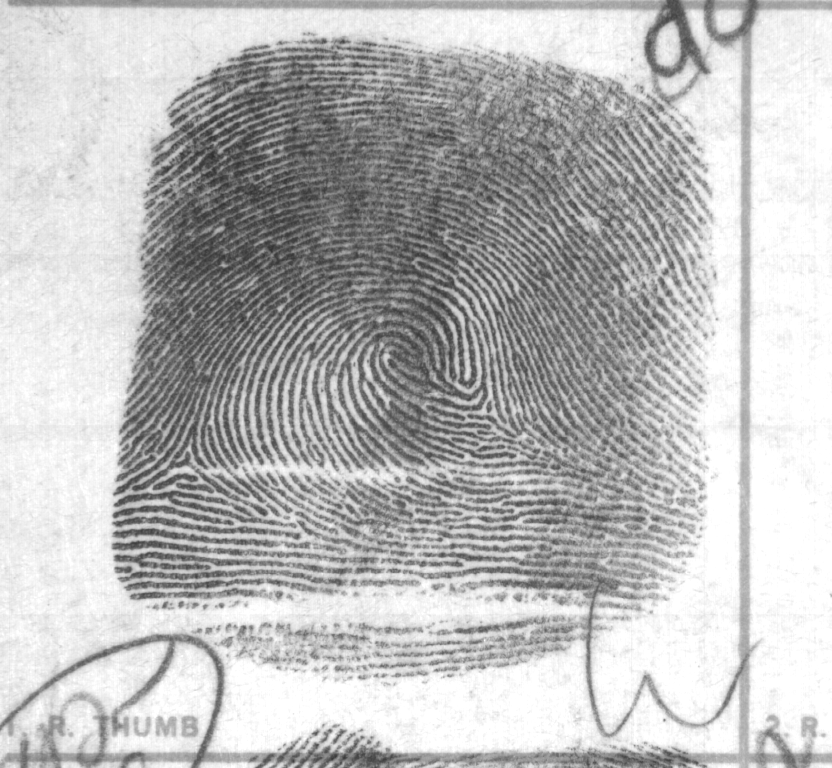
- ROI

    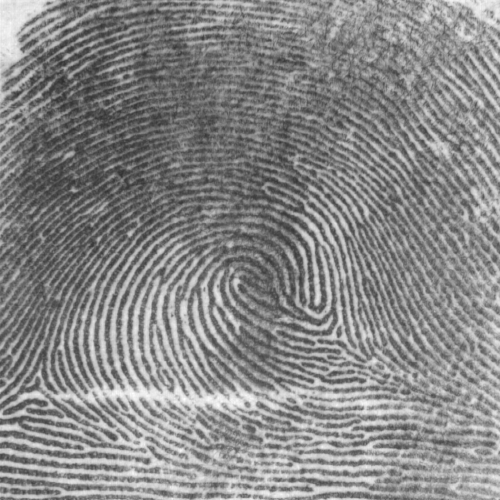
- Ecualizada

    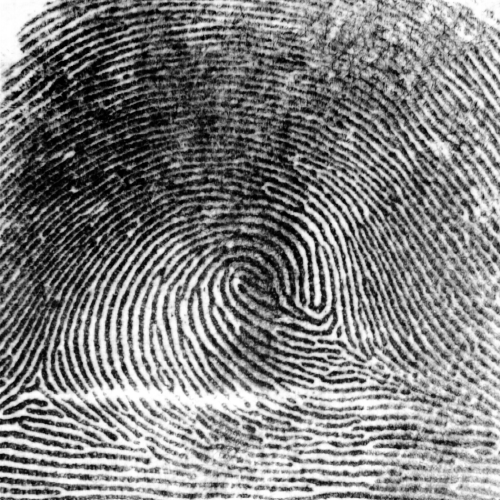
- Filtrada

    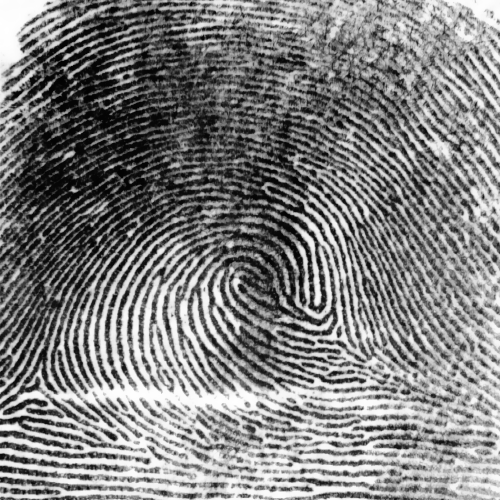
- Sobel

    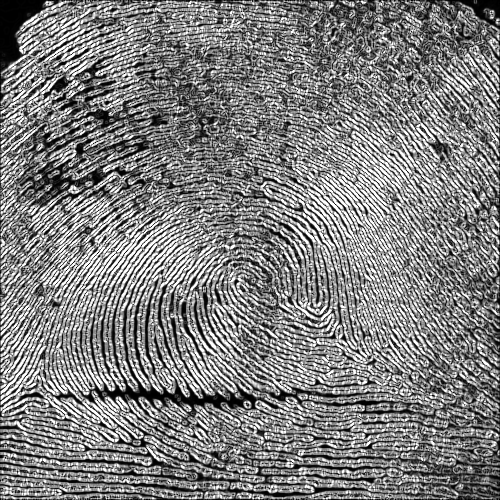
- Refinada

    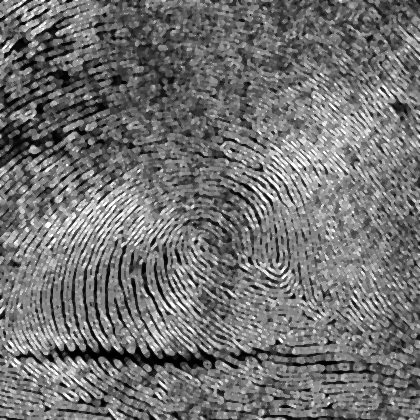

### **Uso de SIFT para BD de huellas dactilares local**
A continuación, implementamos el algoritmo **SIFT (Scale-Invariant Feature Transform)** para extraer las características claves de las huellas dactilares preprocesadas y realizar la coincidencia entre ellas. Para ello, comparamos las huellas dactilares de un mismo usuario consigo mismo y con las de otros usuarios para evaluar la precisión del algoritmo. Utilizamos las siguientes funciones:

- `match_knn_ratio()`: Devuelve los matches entre los descriptores de dos huellas ordenados utilizando el KNN (vecinos más cercanos) y el ratio de Lowe, para comprobar que el match elegido sea el mejor. 
- `calcular_similitud()`: Esta función compara los descriptores SIFT de dos imágenes utilizando el método de coincidencia de características KNN (K-Nearest Neighbors) y devuelve los matches, el ratio de matches, y si se considera un match, es decir, las huellas pertenecen a la misma persona o no.

Estos métodos son reciclados de la práctica 5 de la asignatura, relacionada con la extracción de características.

In [29]:
def match_knn_ratio(bf, des1, des2, ratio=0.75, k=2): # Método reciclado de la práctica 5 de la asignatura
    """
    Empareja descriptores con KNN, aplica el test de ratio de Lowe
    y devuelve los matches ordenados.
    """
    knn = bf.knnMatch(des1, des2, k=k)
    good = []

    for pair in knn:
        if len(pair) < 2:
            continue
        m, n = pair[0], pair[1]

        if m.distance < ratio * n.distance: # ratio de Lowe
            good.append(m)

    return sorted(good, key=lambda x: x.distance)

def calcular_similitud(bf, kp_src, des_src, kp_dst, des_dst, mejor_umbral=-np.inf): # Método reciclado de la práctica 5 de la asignatura
    """Compara dos conjuntos de descriptores y devuelve los inliers, el ratio y si es match."""
    inliers = 0
    ratio = 0.0
    es_match = False
    
    if des_src is None or des_dst is None: 
        return inliers, ratio, es_match
    
    matches = match_knn_ratio(bf, des_src, des_dst)
    good_n = len(matches)
    # Es necesario un mínimo de 4 matches para realizar la homografía
    if good_n >= 4:
        src = np.float32([kp_src[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
        dst = np.float32([kp_dst[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
        # Busca la transformación necesaria para hacer coincidir los puntos de 'src' con los de 'dst'
        # mask indica qué puntos son correctos después de aplicar la transformación
        _, mask = cv.findHomography(src, dst, cv.RANSAC, 5.0)
        if mask is not None:
                inliers = int(mask.sum())
                if len(matches) > 0:
                    ratio = (inliers / len(matches)) * 100.0
                
                # Condición para que se considere match
                # La establecemos a un mínimo de 5 matches correctos
                if inliers >= 5 and ratio >= mejor_umbral:
                    es_match = True
    return inliers, ratio, es_match

- `cargar_dataset()`: Esta función recorre todas las imágenes en la base de datos, carga cada imagen y genera los descriptores SIFT para cada una de ellas, almacenándolos en una estructura de datos para su posterior comparación.

In [ ]:
def cargar_dataset(out_path, sift):
    """Carga las imágenes procesadas y genera descriptores SIFT."""
    dataset = []
    
    # iterar por la carpeta de las imágenes preprocesadas sin coger 
    # las imágenes de test
    users = sorted([u for u in os.listdir(out_path) if u.lower() != "test"])
    
    for user in users:
        folder = os.path.join(out_path, user, "refinadas")
        if not os.path.isdir(folder): 
            continue
        
        files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".png")]) # pedido a Gemini para buscar los ficheros .png
        
        for f in files:
            path = os.path.join(folder, f)
            img = cv.imread(path, cv.IMREAD_GRAYSCALE)
            if img is None: 
                continue
            
            kp, des = sift.detectAndCompute(img, None) # reciclado de la práctica 5 de la asignatura
            
            if des is not None:
                # Idea de Gemini para almacenar los keypoints y los descriptores de cada imagen
                dataset.append({'id': user, 'filename': f, 'kp': kp, 'des': des})
                
    return dataset

- `evaluar_configuracion_sift()`: Crea un descriptor SIFT con los parámetros indicados y calcula la similitud entre pares de imágenes. Para ello utiliza el *Brute-Force Matcher* visto en la asignatura. Devolverá los ratios de inliers de las comparaciones de genuinos e impostores, así como un resumen que indica el número de inliers, el ratio y la decisión tomada.

In [ ]:
def evaluar_configuracion_sift(out_path, params, mejor_umbral=-np.inf):
    """
    Crea el descriptor SIFT y devuelve los ratios de las comparaciones de los genuinos
    y los impostores, así como un resumen de los resultados.
    """
    sift = cv.SIFT_create(**params) # reciclado de la práctica 5 de la asignatura
    bf = cv.BFMatcher() # reciclado de la práctica 5 de la asignatura
    dataset = cargar_dataset(out_path, sift)
    genuinos_ratios = [] # lista para almacenar ratios de genuinos 
    impostores_ratios = [] # lista para almacenar ratios de impostores 
    resumen = [] # lista para almacenar resultados
    for i in range(0, len(dataset)):
        for j in range(i + 1, len(dataset)):
            img_A, img_B = dataset[i], dataset[j]
            inliers, ratio, es_match = calcular_similitud(bf, img_A['kp'], img_A['des'], img_B['kp'], img_B['des'], mejor_umbral)
            
            if img_A['id'] == img_B['id']: # Si es el mismo usuario, añadimos el ratio a la lista genuinos_ratios
                genuinos_ratios.append(ratio)
            else: # Si no es el mismo usuario, añadimos el ratio a la lista impostores_ratios
                impostores_ratios.append(ratio)
            resumen.append([img_A['id'], img_B['id'], inliers, ratio, es_match])
    return genuinos_ratios, impostores_ratios, resumen


- `gestionar_optimizacion_sift()`: Busca los mejores hiperparámetros del descriptor SIFT para obtener el menor **EER (Equal Error Rate)** y guarda la mejor configuración en un fichero JSON para poder utilizarlo sin necesidad de repetir el proceso. Esta función se la pedimos a Gemini.

In [ ]:

def gestionar_optimizacion_sift(out_path, params_file):
    """
    Busca los mejores hiperparámetros del descriptor SIFT para
    minimizar el EER y guarda la mejor configuración en un JSON.
    """
    mejor_config = {}
    buscar = True
    if os.path.exists(params_file):
        print(f"Archivo de configuración encontrado: {params_file}")
        if input("¿Recalcular hiperparámetros (s/n)? ").lower().strip() != 's':
            buscar = False
            with open(params_file, 'r') as f: mejor_config = json.load(f)
            print(f"Configuración cargada: {mejor_config}")
    if buscar:
        print("Iniciando búsqueda de mejores parámetros...")
        param_grid = { # hiperparámetros a probar
            'nfeatures': [1500, 6000, 7000], 
            'contrastThreshold': [0.01, 0.03, 0.04], 
            'edgeThreshold': [10, 15], 
            'sigma': [1.4, 1.6]
            }
        mejor_eer = 100.0
        import itertools
        keys, values = zip(*param_grid.items())
        total_combs = [dict(zip(keys, v)) for v in itertools.product(*values)] # todas las combinaciones entre hiperparámetros
        for idx, params in enumerate(total_combs):
            print(f"Probando [{idx+1}/{len(total_combs)}]: {params} ...", end="")
            genuinos_ratios, impostores_ratios, _ = evaluar_configuracion_sift(out_path, params)
            if not genuinos_ratios or not impostores_ratios: 
                print(" Sin datos.")
                continue
            umbrales = np.linspace(0, 100, 50)
            # Calcula la diferencia entre la tasa de falso rechazo (FRR) y la tasa de falsa aceptación (FAR) para varios umbrales
            diffs = [abs((np.sum(np.array(genuinos_ratios) < u)/len(genuinos_ratios)) - (np.sum(np.array(impostores_ratios) >= u)/len(impostores_ratios))) for u in umbrales]
            # Escoge la diferencia mínima
            eer_local = min(diffs) * 100
            print(f" EER aprox: {eer_local:.2f}")
            if eer_local < mejor_eer:
                mejor_eer = eer_local
                mejor_config = params
        print(f"Mejor configuración guardada con EER={mejor_eer:.2f}")
        with open(params_file, 'w') as f: json.dump(mejor_config, f)
    return mejor_config

In [ ]:
PARAMS_FILE = "mejor_config_sift.json"
mejor_config = gestionar_optimizacion_sift(OUT_PATH, PARAMS_FILE)

Archivo de configuración encontrado: mejor_config_sift.json
Iniciando búsqueda de mejores parámetros...
Probando [1/36]: {'nfeatures': 1500, 'contrastThreshold': 0.01, 'edgeThreshold': 10, 'sigma': 1.4} ... EER aprox: 0.00
Probando [2/36]: {'nfeatures': 1500, 'contrastThreshold': 0.01, 'edgeThreshold': 10, 'sigma': 1.6} ... EER aprox: 9.03
Probando [3/36]: {'nfeatures': 1500, 'contrastThreshold': 0.01, 'edgeThreshold': 15, 'sigma': 1.4} ... EER aprox: 1.39
Probando [4/36]: {'nfeatures': 1500, 'contrastThreshold': 0.01, 'edgeThreshold': 15, 'sigma': 1.6} ... EER aprox: 4.17
Probando [5/36]: {'nfeatures': 1500, 'contrastThreshold': 0.03, 'edgeThreshold': 10, 'sigma': 1.4} ... EER aprox: 0.00
Probando [6/36]: {'nfeatures': 1500, 'contrastThreshold': 0.03, 'edgeThreshold': 10, 'sigma': 1.6} ... EER aprox: 9.03
Probando [7/36]: {'nfeatures': 1500, 'contrastThreshold': 0.03, 'edgeThreshold': 15, 'sigma': 1.4} ... EER aprox: 1.39
Probando [8/36]: {'nfeatures': 1500, 'contrastThreshold': 0.03,

Ejecutamos el verificador de huellas con los mejores hiperparámetros encontrados sobre todo el conjunto de datos:

In [47]:
genuinos_train, impostores_train, resumen = evaluar_configuracion_sift(OUT_PATH, mejor_config)
df = pd.DataFrame(resumen, columns=["img A", "img B", "inliers", "ratio", "es_match"])
df.head()

,img A,img B,inliers,ratio,es_match
0,crd_0811f,crd_0811f,5,62.5,True
1,crd_0811f,crd_0813f,4,100.0,False
2,crd_0811f,crd_0813f,4,80.0,False
3,crd_0811f,crd_0814f,0,0.0,False
4,crd_0811f,crd_0814f,4,100.0,False


A continuación, vemos cómo ha rendido el modelo observando los falsos/verdaderos positivos y negativos.

In [ ]:
# Función pedida a Gemini para extraer el identificador de usuario
def extraer_id_numerico(nombre_archivo):
    """Extrae el identificador de usuario del nombre del archivo introducido."""
    # Convertimos a string y quitamos extensión por seguridad
    s = str(nombre_archivo).split('.')[0] 
    
    # Si la cadena no está vacía, ignoramos el último caracter
    if len(s) > 0:
        s = s[:-1] 
    
    # Filtramos para dejar SOLO los números ("crd_0811" -> "0811")
    id_numerico = ''.join(filter(str.isdigit, s))
    
    return id_numerico

def clasificar(fila):
    """
    Clasifica un resultado en: True Positive, True Negative,
    False Positive o False Negative."""
    id_a = extraer_id_numerico(fila['img A'])
    id_b = extraer_id_numerico(fila['img B'])
    misma_persona = (id_a == id_b)
    resultado = fila['es_match']
    
    if misma_persona and resultado:
        return "TP"
    elif not misma_persona and not resultado:
        return "TN"
    elif not misma_persona and resultado:
        return "FP"
    elif misma_persona and not resultado:
        return "FN"
        
    return "Error"

# Aplicamos la función clasificar a cada fila del dataframe
df["result"] = df.apply(clasificar, axis=1)
print(df[["img A", "img B", "es_match", "result"]].head())

# Mostramos el conteo de cada resultado posible
conteo = df["result"].value_counts()
print(conteo)

# Pedido a Gemini para calcular el accuracy
TP = conteo.get("TP", 0)
TN = conteo.get("TN", 0)
FP = conteo.get("FP", 0)
FN = conteo.get("FN", 0)

accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP+TN+FP+FN) > 0 else 0
print(f"Accuracy (Exactitud): {accuracy*100:.2f}%")

       img A      img B  es_match result
0  crd_0811f  crd_0811f      True     TP
1  crd_0811f  crd_0813f     False     TN
2  crd_0811f  crd_0813f     False     TN
3  crd_0811f  crd_0814f     False     TN
4  crd_0811f  crd_0814f     False     TN
result
TN    132
FP     12
FN      7
TP      2
Name: count, dtype: int64
Accuracy (Exactitud): 87.58%


A continuación, buscamos el umbral óptimo. Este es aquel que obtiene un valor equilibrado de FAR (falsa aceptación) y FRR (falso rechazo). Luego, guardamos el umbral en un fichero para su posterior uso. La función se la pedimos a ChatGPT.

In [53]:
# Función pedida a ChatGPT
def calcular_umbral_optimo(genuinos, impostores):
    """Calcula el umbral óptimo, donde FRR-FAR es mínimo."""
    umbrales = np.linspace(0, 100, 500)
    gen_arr, imp_arr = np.array(genuinos), np.array(impostores)
    diffs = []
    for u in umbrales:
        frr = np.sum(gen_arr < u) / len(gen_arr) if len(gen_arr) else 0
        far = np.sum(imp_arr >= u) / len(imp_arr) if len(imp_arr) else 0
        diffs.append(abs(frr*100 - far*100))
    return umbrales[np.argmin(diffs)]

mejor_umbral = calcular_umbral_optimo(genuinos_train, impostores_train)

with open("mejor_umbral.txt", 'w') as f:
    f.write(str(mejor_umbral))
print(f"Umbral óptimo calculado: {mejor_umbral:.2f}%")

Umbral óptimo calculado: 44.49%


### **Visualización de los resultados**
Se busca comparar realizar una gráfica donde se muestren los 4 casos posibles de comparación de huellas dactilares:

- True Positive (TP): Comparación de huellas del mismo usuario que coinciden correctamente.

- True Negative (TN): Comparación de huellas de diferentes usuarios que no coinciden correctamente.

- False Positive (FP): Comparación de huellas de diferentes usuarios que coinciden incorrectamente.

- False Negative (FN): Comparación de huellas del mismo usuario que no coinciden incorrectamente.

Para ello se ha utilizado la función `dibujar_curvas_error` que utiliza los valores de salida de la función `comparar_huellas` para generar la gráfica que son dos campanadas de Gauss superpuestas, donde se puede ver qué tan bien separa el sistema a los usuarios genuinos(curva roja) de los impostores(curva azul).

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def dibujar_gaussiana_error(genuinos_similitud, impostores_similitud, umbral_similitud):
    plt.figure(figsize=(8, 6))
    
    # 1. CONVERSIÓN DE DATOS (Similitud -> Error)
    # Error = 100 - Similitud.
    # Genuinos (0 error ideal) estarán a la izquierda.
    # Impostores (100 error ideal) estarán a la derecha.
    gen_err = [100 - x for x in genuinos_similitud]
    imp_err = [100 - x for x in impostores_similitud]
    umbral_error = 100 - umbral_similitud
    
    x = np.linspace(0, 100, 500)
    
    # --- ESTÉTICA (Igual a tu petición) ---
    plt.gca().set_facecolor('#f0f0f0') 

    # --- GENUINOS (NARANJA - tab:orange) ---
    # Ahora están a la IZQUIERDA (Bajo error).
    if len(gen_err) > 1:
        mu, std = norm.fit(gen_err)
        y = norm.pdf(x, mu, std)
        plt.plot(x, y, color='tab:orange', lw=3, label='Genuinos')
        
        # FRR (Falso Rechazo): Cuando un Genuino tiene DEMASIADO error (está a la DERECHA del umbral)
        # Nota: La condición cambia a (x > umbral)
        plt.fill_between(x, y, 0, where=(x > umbral_error), 
                         facecolor='tab:orange', alpha=0.4, hatch='///', label='FRR')

    # --- IMPOSTORES (AZUL - tab:blue) ---
    # Ahora están a la DERECHA (Alto error).
    if len(imp_err) > 1:
        mu, std = norm.fit(imp_err)
        y = norm.pdf(x, mu, std)
        plt.plot(x, y, color='tab:blue', lw=3, label='Impostores')
        
        # FAR (Falsa Aceptación): Cuando un Impostor tiene MUY POCO error (está a la IZQUIERDA del umbral)
        # Nota: La condición cambia a (x <= umbral)
        plt.fill_between(x, y, 0, where=(x <= umbral_error), 
                         facecolor='tab:blue', alpha=0.4, hatch='///', label='FAR')

    # --- UMBRAL ---
    plt.axvline(x=umbral_error, color='k', linestyle='--', label=f'Umbral Error {umbral_error:.1f}')
    
    plt.title('Distribución de Error (Distancia)')
    plt.xlabel('Magnitud de Error (0=Idéntico, 100=Diferente)')
    plt.ylabel('Densidad')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


#### Ejecución de visualización de resultados

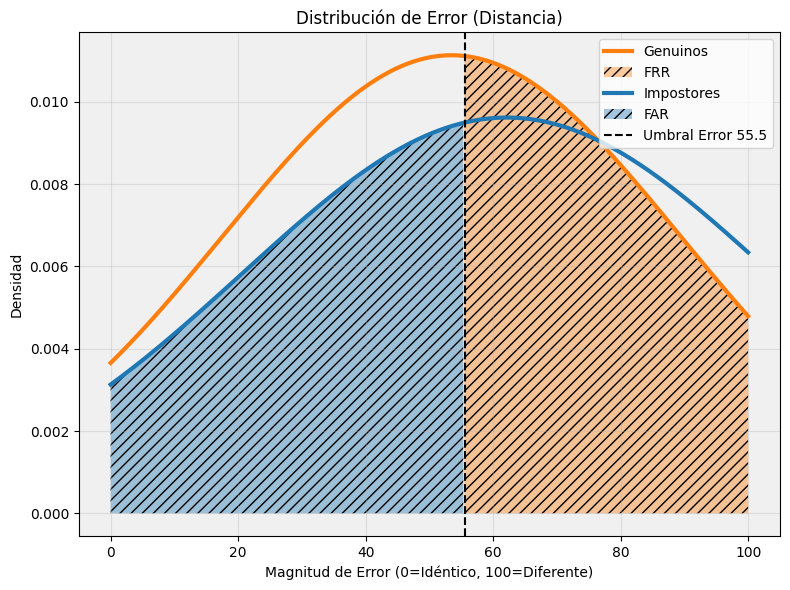

In [36]:
dibujar_gaussiana_error(genuinos_train, impostores_train, mejor_umbral)

In [37]:
import matplotlib.pyplot as plt
import numpy as np

def dibujar_det_con_eer(genuinos, impostores, umbral):
    """
    Dibuja la curva DET, el EER (Equal Error Rate) y el punto (FAR, FRR) dado un umbral.
    """
    genuinos = np.array(genuinos)
    impostores = np.array(impostores)
    
    # 1. Calculamos la curva barriendo umbrales
    umbrales = np.linspace(0, 100, 1000)
    far_list = []
    frr_list = []
    
    for u in umbrales:
        # FAR: % Impostores que pasan (Score >= umbral)
        far = np.mean(impostores >= u) if len(impostores) > 0 else 0
        # FRR: % Genuinos que fallan (Score < umbral)
        frr = np.mean(genuinos < u) if len(genuinos) > 0 else 0
        
        far_list.append(far)
        frr_list.append(frr)
        
    # 2. ENCONTRAR EL EER (Cálculo Automático)
    # Buscamos el índice donde la diferencia entre FAR y FRR es mínima
    diferencias = np.abs(np.array(far_list) - np.array(frr_list))
    idx_eer = np.argmin(diferencias)
    
    eer_valor = far_list[idx_eer] # Este es el % de error (ej: 0.05 para 5%)
    umbral_eer = umbrales[idx_eer] # Este es el umbral que logra ese EER
    
    print(f"--- RESULTADO EER ---")
    print(f"EER (Error): {eer_valor*100:.2f}%")
    print(f"Umbral para lograr EER: {umbral_eer:.2f}")

    # 3. GRAFICAR
    plt.figure(figsize=(8, 8))
    
    # Curva DET
    plt.plot(far_list, frr_list, color='#66b032', lw=3, label='Curva DET')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', alpha=0.5)
    f_op = np.mean(impostores >= umbral)
    r_op = np.mean(genuinos < umbral)
    plt.plot(f_op, r_op, 'ro', markersize=10, label=f'Op (U={umbral:.2f})')
    plt.annotate(f'Punto operativo\n(Umbral: {umbral:.2f})', 
                 xy=(f_op, r_op), xytext=(f_op+0.05, r_op))

    plt.title('Curva DET con EER')
    plt.xlabel('Falsa Aceptación (FAR)')
    plt.ylabel('Falso Rechazo (FRR)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    
    plt.tight_layout()
    plt.show()


--- RESULTADO EER ---
EER (Error): 44.44%
Umbral para lograr EER: 44.44


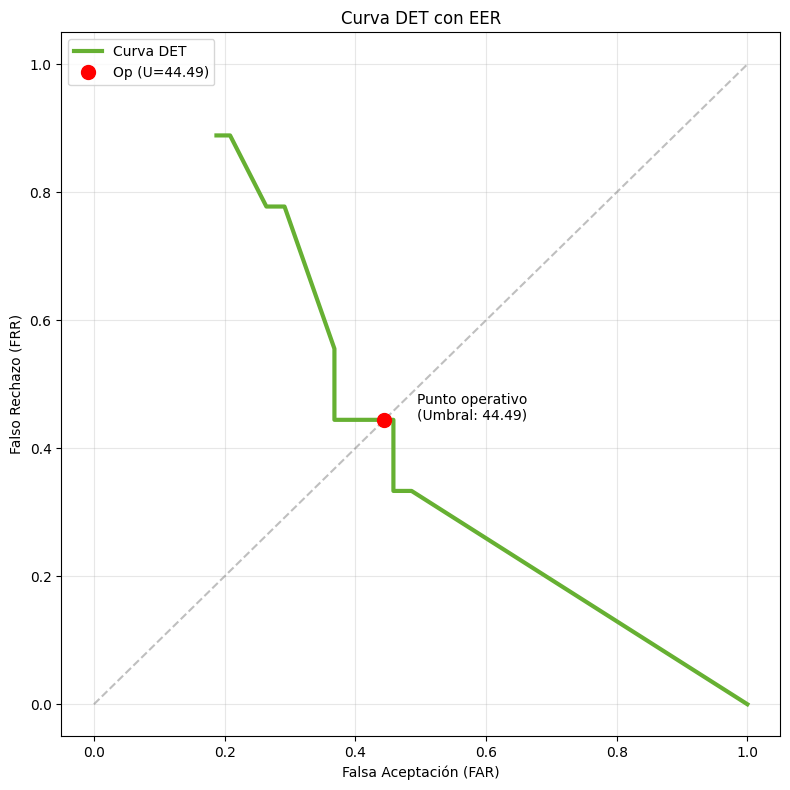

In [38]:
dibujar_det_con_eer(genuinos_train, impostores_train, mejor_umbral)

In [39]:
def dibujar_curvas_entrenamiento(genuinos, impostores, umbral):
    """Dibuja las curvas de distribución gaussiana y DET con el umbral óptimo."""

    if len(genuinos) == 0 or len(impostores) == 0: return
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    max_val = max(np.max(genuinos), np.max(impostores))
    x_range = np.linspace(0, max_val * 1.2, 500)
    

    t = np.linspace(0, max_val * 1.2, 1000)[:, np.newaxis]
    far_list = np.mean(impostores >= t, axis=1)
    frr_list = np.mean(genuinos < t, axis=1)
    ax2.plot(far_list, frr_list, 'b-', lw=3, label='Curva DET')
    f_op = np.mean(impostores >= umbral)
    r_op = np.mean(genuinos < umbral)
    ax2.plot(f_op, r_op, 'ro', markersize=10, label=f'Op (U={umbral:.2f})')
    ax2.set_title('Curva DET'); ax2.set_xscale('log'); ax2.set_yscale('log')
    ax2.grid(True, which='both', alpha=0.5); ax2.legend()
    plt.tight_layout(); plt.show()


**Conclusiones**

Se puede observar como las gráficas se encuentran solapadas, lo que indica que el sistema tiene dificultades para distinguir entre los usuarios genuinos y los impostores. Esto implica que seguramente haya algun proceso del preprocesamiento que esta influyendo al mal funcionamiento de SIFT. Pudiendo ser, la aplicación del Sobel que puede estar eliminando detalles en la huella dactilar.

### **Evaluación**

In [ ]:
import json
import numpy as np
import cv2 as cv
import os
import pandas as pd

def cargar_dataset_test(out_path, sift):
    """Carga las imágenes procesadas y genera descriptores SIFT."""

    dataset = []
    
    folder = os.path.join(out_path, "test", "refinadas")
    files = sorted([f for f in os.listdir(folder) if f.lower().endswith(".png")])
        
    for f in files:
        path = os.path.join(folder, f)
        img = cv.imread(path, cv.IMREAD_GRAYSCALE)
        if img is None: 
            continue
        
        kp, des = sift.detectAndCompute(img, None)
        
        if des is not None:
            dataset.append({'filename': f, 'kp': kp, 'des': des})
            
    return dataset

def match_knn_ratio(bf, des1, des2, ratio=0.75, k=2): # Método reciclado de la práctica 5 de la asignatura
    """
    Empareja descriptores con KNN, aplica el test de ratio de Lowe
    y devuelve los matches ordenados.
    """
    knn = bf.knnMatch(des1, des2, k=k)
    good = []

    for pair in knn:
        if len(pair) < 2:
            continue
        m, n = pair[0], pair[1]

        if m.distance < ratio * n.distance: # ratio de Lowe
            good.append(m)

    return sorted(good, key=lambda x: x.distance)


def calcular_similitud(bf, kp_src, des_src, kp_dst, des_dst, mejor_umbral=-np.inf): # Método reciclado de la práctica 5 de la asignatura
    """Compara dos conjuntos de descriptores y devuelve inliers, ratio y si es match."""
    inliers = 0
    ratio = 0.0
    es_match = False
    
    if des_src is None or des_dst is None: 
        return inliers, ratio, es_match
    
    matches = match_knn_ratio(bf, des_src, des_dst)
    good_n = len(matches)
    if good_n >= 4:
        src = np.float32([kp_src[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
        dst = np.float32([kp_dst[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)
        _, mask = cv.findHomography(src, dst, cv.RANSAC, 5.0)
        if mask is not None:
                inliers = int(mask.sum())
                if len(matches) > 0:
                    ratio = (inliers / len(matches)) * 100.0
                
                if inliers >= 5 and ratio >= mejor_umbral:
                    es_match = True
    return inliers, ratio, es_match

def ejecutar_autenticacion(reference_path, test_path, params, mejor_umbral=-np.inf):
    sift = cv.SIFT_create(**params)
    bf = cv.BFMatcher()
    dataset = cargar_dataset_test(test_path, sift)

    img = cv.imread(reference_path, cv.IMREAD_GRAYSCALE)
    kp, des = sift.detectAndCompute(img, None)
    
    resumen = []
    for i in range(0, len(dataset)):
        img_B = dataset[i]
        inliers, ratio, es_match = calcular_similitud(bf, kp, des, img_B['kp'], img_B['des'], mejor_umbral)
        resumen.append([reference_path.replace('\\', '/').split('/')[-1], img_B['filename'], inliers, ratio, es_match])
    return resumen

In [44]:
# Función de Gemini
def seleccionar_imagen_referencia(carpeta_huellas):
    """
    Permite al usuario seleccionar una imagen de referencia de una carpeta.
    Retorna la ruta completa de la imagen seleccionada.
    """
    if not os.path.exists(carpeta_huellas):
        print(f"ERROR: No existe la carpeta {carpeta_huellas}")
        return None
    
    imagenes = sorted([f for f in os.listdir(carpeta_huellas) if f.lower().endswith('.png')])
    
    if not imagenes:
        print(f"ERROR: No se encontraron imágenes en {carpeta_huellas}")
        return None
    
    print("\n--- SELECCIÓN DE IMAGEN DE REFERENCIA ---")
    for i, img in enumerate(imagenes):
        print(f"[{i}] {img}")
    
    try:
        sel_img = int(input(f"Elige ID de imagen (0-{len(imagenes)-1}): ").strip())
        ref_imagen = imagenes[sel_img]
    except (ValueError, IndexError):
        print(f"Selección inválida. Usando la primera: {imagenes[0]}")
        ref_imagen = imagenes[0]
    
    reference_path = os.path.join(carpeta_huellas, ref_imagen)
    print(f"\nImagen de referencia: {ref_imagen.split("/")[-1]}\n")
    
    return reference_path

In [45]:

PARAMS_FILE = "mejor_config_sift.json"
with open(PARAMS_FILE, 'r') as f: 
    mejor_config = json.load(f)
    print(f"Configuración cargada: {mejor_config}")
with open("mejor_umbral.txt", 'r') as f:
    mejor_umbral = float(f.read())

reference_path = seleccionar_imagen_referencia("output/test/refinadas")
resumen = ejecutar_autenticacion(reference_path,
                       "output",
                       mejor_config,
                       mejor_umbral)
df = pd.DataFrame(resumen, columns=["img A", "img B", "inliers", "ratio", "es_match"])
df

Configuración cargada: {'nfeatures': 1500, 'contrastThreshold': 0.01, 'edgeThreshold': 10, 'sigma': 1.4}

--- SELECCIÓN DE IMAGEN DE REFERENCIA ---
[0] crd_0811f_01.png
[1] crd_0811s_01.png
[2] crd_0813f_01.png
[3] crd_0813s_01.png
[4] crd_0814f_01.png
[5] crd_0814s_01 copy.png
[6] crd_0814s_01.png
[7] crd_0815f_01 copy.png
[8] crd_0815f_01.png
[9] crd_0815s_01.png

Imagen de referencia: crd_0811f_01.png



,img A,img B,inliers,ratio,es_match
0,crd_0811f_01.png,crd_0811f_01.png,1500,100.0,True
1,crd_0811f_01.png,crd_0811s_01.png,5,62.5,True
2,crd_0811f_01.png,crd_0813f_01.png,4,100.0,False
3,crd_0811f_01.png,crd_0813s_01.png,4,80.0,False
4,crd_0811f_01.png,crd_0814f_01.png,0,0.0,False
5,crd_0811f_01.png,crd_0814s_01 copy.png,4,100.0,False
6,crd_0811f_01.png,crd_0814s_01.png,4,100.0,False
7,crd_0811f_01.png,crd_0815f_01 copy.png,4,100.0,False
8,crd_0811f_01.png,crd_0815f_01.png,4,100.0,False
9,crd_0811f_01.png,crd_0815s_01.png,4,100.0,False


**Conclusiones**

Se puede observar que da buenos resultados, pero este caso es así porque los datos que se usan son copias de los datos anteriores y esta comparando huellas consigo misma, entonces no son huellas tomadas en condiciones reales.